# MVTec Leather Dataset Exploration

## Initial imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# Base path to the leather dataset
DATA_ROOT = "../data/mvtc/leather"

# Verify the folder exists
print("Contents of leather dataset:", os.listdir(DATA_ROOT))

Contents of leather dataset: ['ground_truth', 'license.txt', 'readme.txt', 'test', 'train']


## Display of 4 good and 4 defective images side by side

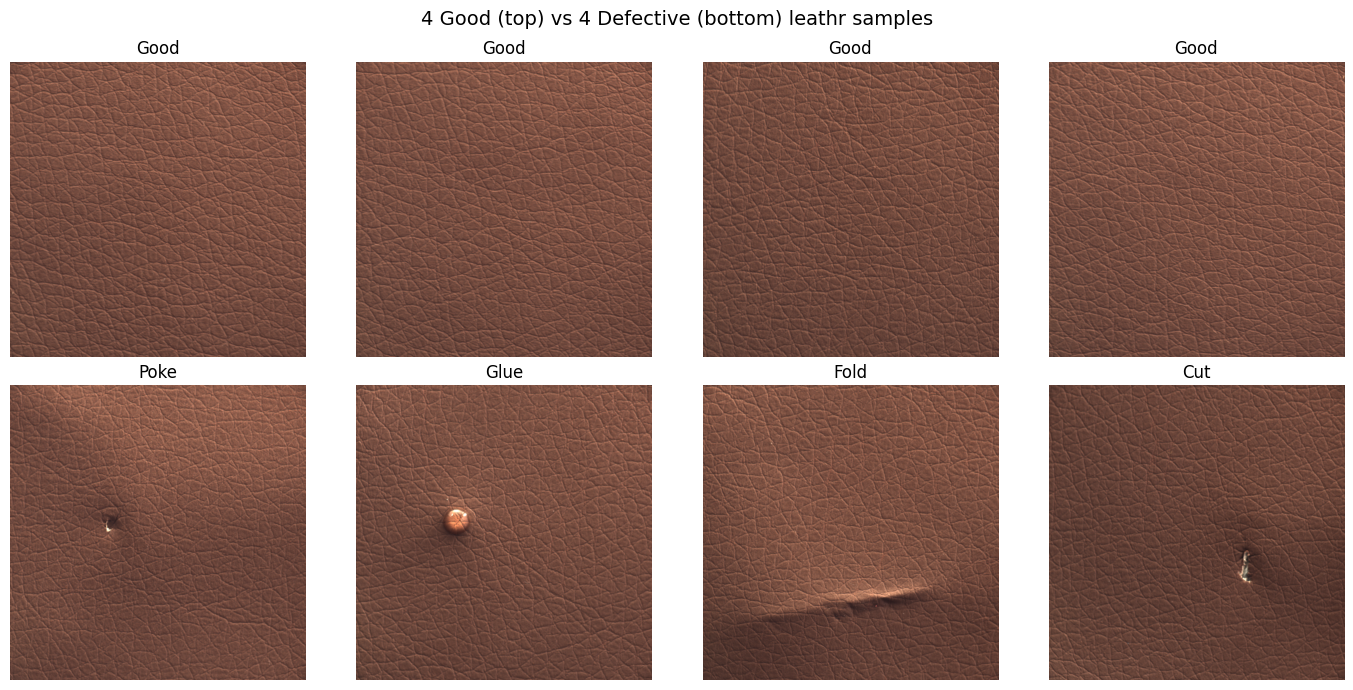

In [15]:
# we pick 4 random images from the dataset
good_dir = os.path.join(DATA_ROOT, "test", "good")
defect_dirs = [
    os.path.join(DATA_ROOT, "test", defect)
    for defect in ["color", "cut", "fold", "glue", "poke"]
]

# then we pick 4 random images
good_images = random.sample(os.listdir(good_dir), 4)
good_images = [os.path.join(good_dir, f) for f in good_images]

# and we pick 1 image for each defect type
defect_images = []
for d in random.sample(defect_dirs, 4):
    files = os.listdir(d)
    if files:
        defect_images.append(os.path.join(d, random.choice(files)))

# and we can plot
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, img_path in enumerate(good_images):
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Good")
    axes[0, i].axis("off")

for j, img_path in enumerate(defect_images):
    img = Image.open(img_path)
    axes[1, j].imshow(img)
    # extract defect type from path
    defect_type = img_path.split(os.sep)[-2]
    axes[1, j].set_title(defect_type.capitalize())
    axes[1, j].axis("off")

plt.suptitle("4 Good (top) vs 4 Defective (bottom) leathr samples", fontsize=14)
plt.tight_layout()
plt.show()

### Comment
After displaying the good and defective images side by side, we can notice that some defects are more obvious (like glue or fold) than others (like a little poke or cut)

In [ ]:
# How many files in each subfolder of test/
test_path = os.path.join(DATA_ROOT, "test")
categories = os.listdir(test_path)
counts = {}
for cat in categories:
    counts[cat] = len(os.listdir(os.path.join(test_path, cat)))

# we also count training good images
train_good = os.path.join(DATA_ROOT, "train", "good")
counts["train/good"] = len(os.listdir(train_good))

print("Image counts:")
for k, v in counts.items():
    print(f"  {k:30s}: {v}")

Categories in test folder: ['color', 'cut', 'fold', 'glue', 'good', 'poke']
Image counts:
  color                         : 19
  cut                           : 19
  fold                          : 17
  glue                          : 19
  good                          : 32
  poke                          : 18
  train/good                    : 245


### Comment
With the image count we can see that all classes do not have the same number of samples but the number only varies between 17 and 19 appart from the good samples in train/good which numbe is 13 times bigger than the other classes.

## Ground truth mask alongside defective images

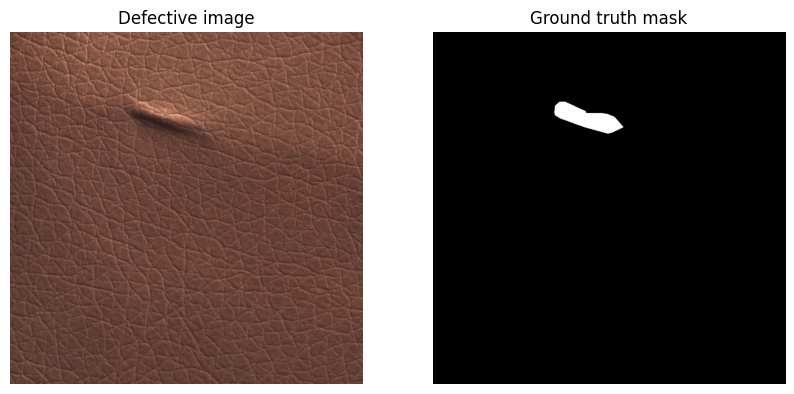

In [33]:
# For a chosen defect type, we display the first image and its mask
defect = "fold"  
img_dir = os.path.join(DATA_ROOT, "test", defect)
mask_dir = os.path.join(DATA_ROOT, "ground_truth", defect)

# Get one filename cause the mask has the same name
sample = os.listdir(img_dir)[0]
img_path = os.path.join(img_dir, sample)
mask_path = os.path.join(mask_dir, sample[:sample.rfind(".")]) + "_mask.png"  # image concat with _mask

img = Image.open(img_path)
mask = Image.open(mask_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title("Defective image")
axes[0].axis("off")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Ground truth mask")
axes[1].axis("off")
plt.show()

### Comment
The mask is a binary image (in black and white) where white pixels mark the defect. We can see how the white pixels on the mask are perfectly aligned with the defect zone on the left image.

## Some statistics

In [37]:
from PIL import ImageStat

def get_image_stats(image_dir):
    widths, heights = [], []
    mean_pixels = []
    for fname in os.listdir(image_dir):
        fp = os.path.join(image_dir, fname)
        try:
            img = Image.open(fp).convert("RGB")
            w, h = img.size
            widths.append(w)
            heights.append(h)
            stat = ImageStat.Stat(img)
            mean_pixels.append(np.mean(stat.mean))  # average color intensity
        except Exception as e:
            print(f"Error with {fp}: {e}")
    return widths, heights, mean_pixels

# Only use test/good for consistent statistics
test_good_dir = os.path.join(DATA_ROOT, "test", "good")
w_list, h_list, m_list = get_image_stats(test_good_dir)

print(f"Average width : {np.mean(w_list):.1f} +/- {np.std(w_list):.1f}")
print(f"Average height: {np.mean(h_list):.1f} +/- {np.std(h_list):.1f}")
print(f"Average pixel intensity: {np.mean(m_list):.1f} +/- {np.std(m_list):.1f}")
print(f"Number of good test images: {len(w_list)}")

# Class distribution summary
print("\nClass distribution (test set):")
total_test = sum(counts[cat] for cat in counts)
for cat, num in counts.items():
    print(f"  {cat:20s}: {num} ({num/total_test*100:.1f}%)")

Average width : 1024.0 +/- 0.0
Average height: 1024.0 +/- 0.0
Average pixel intensity: 85.4 +/- 2.5
Number of good test images: 32

Class distribution (test set):
  color               : 19 (5.1%)
  cut                 : 19 (5.1%)
  fold                : 17 (4.6%)
  glue                : 19 (5.1%)
  good                : 32 (8.7%)
  poke                : 18 (4.9%)
  train/good          : 245 (66.4%)


## Now let's check if yolo draws the bounding bow correctly

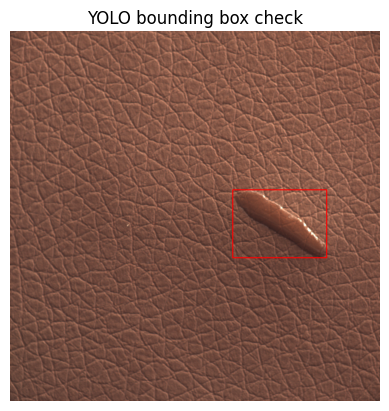

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os, random

yolo_dir = "../data/yolo"
img_dir = os.path.join(yolo_dir, "images", "train")
lbl_dir = os.path.join(yolo_dir, "labels", "train")

# we pick a random image that has a non-empty label file
all_files = os.listdir(img_dir)
random.shuffle(all_files)
for fname in all_files:
    lbl_path = os.path.join(lbl_dir, fname.rsplit(".",1)[0]+".txt")
    if os.path.getsize(lbl_path) > 0:
        break

img = cv2.imread(os.path.join(img_dir, fname))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]

with open(lbl_path) as f:
    line = f.readline().strip()
    class_id, cx, cy, w, h = map(float, line.split())
    # Denormalize
    x1 = int((cx - w/2) * W)
    y1 = int((cy - h/2) * H)
    x2 = int((cx + w/2) * W)
    y2 = int((cy + h/2) * H)
    cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)

plt.imshow(img)
plt.title("YOLO bounding box check")
plt.axis("off")
plt.show()

### Comment
To summarize, all images are perfectly the same size (preprocessed by MVTec). Also we notice that 66.4% of the images display good and the defective classes are all around 5% of all the training dataset (many good, few defective).